# Multi-animal interaction data for Airscope 

This notebook is a public, reproducible walkthrough for the released multi-animal PICO/Airscope example dataset. It assumes the release files have already been downloaded and placed in `DATA_DIR`.

The workflow covers:

1. Configure the local data directory and verify the release files.
2. Load `data_aligned.mat` and inspect the aligned calcium and behavior arrays.
3. Preview the behavior video and SAM2 instance masks.
4. Detect mouse-mouse contact events from segmentation masks.
5. Plot interaction rasters for a focal animal.
6. Overlay interaction epochs on calcium activity from selected cortical regions.

Data source: https://drive.google.com/drive/folders/1g2-mHKbvAN6hFg_vgefyA6oTYkXPSHUd?dmr=1&ec=wgc-drive-%5Bmodule%5D-goto


## 0. Reproducibility notes

Expected release files in `DATA_DIR`:

| File | Purpose |
| --- | --- |
| `behavior.mp4` | Raw multi-animal behavior video. |
| `behavior_with_mask.avi` | Behavior video with SAM2 masks overlaid for visual inspection. |
| `segment_mask.pickle` | Gzip-compressed pickle containing `numpy.packbits` masks for each video frame. |
| `data_aligned.mat` | Aligned calcium traces, cortical labels, neuron centers, mouse centers, and timestamps. |

The aligned interval is behavior frames `2918` to `10518` inclusive, sampled at `10 fps`, for `7601` aligned frames.

The notebook intentionally avoids loading all unpacked masks into memory. Each mask frame is unpacked only when it is plotted or analyzed.


## 1. Imports and plotting defaults

This cell imports the packages used throughout the notebook and sets publication-friendly plotting defaults.


In [1]:
from __future__ import annotations

import gzip
import itertools
import pickle
from pathlib import Path
from typing import Any

import numpy as np
import scipy.io as sio
from scipy.ndimage import distance_transform_edt
from scipy.stats import zscore
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import cv2

import pandas as pd

plt.rcParams.update({
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


/data/home/angran/anaconda3/envs/PICO/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configure paths

Download the release files from the Google Drive link in the README, then place these four files in one local folder:

- `behavior.mp4`
- `behavior_with_mask.avi`
- `segment_mask.pickle`
- `data_aligned.mat`

Set `DATA_DIR` below to that folder. If you put the files in the same directory where this notebook is running, the default `Path(".")` works.


In [3]:
# Set this to the folder containing the four downloaded release files.

DATA_DIR = Path("/mnt/nas02/LAR/pico/data_release/multi_animal")

OUTPUT_DIR = Path("./outputs/").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEHAVIOR_MP4_PATH = DATA_DIR / "behavior.mp4"
BEHAVIOR_WITH_MASK_PATH = DATA_DIR / "behavior_with_mask.avi"
SAM2_MASK_PATH = DATA_DIR / "segment_mask.pickle"
ALIGNED_DATA_PATH = DATA_DIR / "data_aligned.mat"

EXPECTED_FILES = {
    "behavior.mp4": BEHAVIOR_MP4_PATH,
    "behavior_with_mask.avi": BEHAVIOR_WITH_MASK_PATH,
    "segment_mask.pickle": SAM2_MASK_PATH,
    "data_aligned.mat": ALIGNED_DATA_PATH,
}

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Data directory: /mnt/nas02/LAR/pico/data_release/multi_animal
Output directory: /data/home/angran/BBNC/code/PICO/PICO_release/Airscope_toolbox/Data_release/experiments/muiti_animal_interaction/outputs


## 3. Verify the local release files

This check fails early if files are missing, and reports file sizes so readers can verify that large downloads completed successfully.


In [4]:
def human_size(num_bytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f"{value:.1f} {unit}"
        value /= 1024
    return f"{value:.1f} TB"


def verify_release_files(expected_files: dict[str, Path]) -> list[dict[str, str]]:
    rows = []
    missing = []
    for name, path in expected_files.items():
        exists = path.exists()
        if not exists:
            missing.append(name)
        rows.append({
            "file": name,
            "exists": str(exists),
            "size": human_size(path.stat().st_size) if exists else "missing",
            "path": str(path),
        })

    if pd is not None:
        display(pd.DataFrame(rows))
    else:
        for row in rows:
            print(row)

    if missing:
        missing_text = ", ".join(missing)
        raise FileNotFoundError(
            f"Missing release file(s): {missing_text}. "
            f"Place the downloaded release files in DATA_DIR or update DATA_DIR to the existing release folder."
        )
    return rows


file_manifest = verify_release_files(EXPECTED_FILES)


,file,exists,size,path
0,behavior.mp4,True,326.7 MB,/mnt/nas02/LAR/pico/data_release/multi_animal/...
1,behavior_with_mask.avi,True,277.4 MB,/mnt/nas02/LAR/pico/data_release/multi_animal/...
2,segment_mask.pickle,True,18.7 MB,/mnt/nas02/LAR/pico/data_release/multi_animal/...
3,data_aligned.mat,True,1.2 GB,/mnt/nas02/LAR/pico/data_release/multi_animal/...


## 4. Load and inspect `data_aligned.mat`

The `.mat` file is the compact entry point for calcium traces and behavior alignment. It contains one calcium matrix per animal, cortical labels for each neuron, neuron center coordinates, and behavior-video mouse center coordinates.


In [5]:
ANIMAL_ID_TO_NAME = {
    1: "03_new",
    2: "05_new",
    3: "80",
    4: "06_new",
    5: "07",
}

ANIMAL_COLORS = {
    1: "tab:orange",
    2: "tab:green",
    3: "lightcoral",
    4: "plum",
    5: "saddlebrown",
}

FRAME_SHAPE = (944, 968)  # height, width in pixels
VIDEO_FPS = 10.0

aligned_data = sio.loadmat(ALIGNED_DATA_PATH, simplify_cells=True)

START_FRAME = int(np.asarray(aligned_data["start_frame"]).item())
END_FRAME = int(np.asarray(aligned_data["end_frame"]).item())
N_ALIGNED_FRAMES = END_FRAME - START_FRAME + 1

print(f"Aligned behavior frames: {START_FRAME} to {END_FRAME} inclusive")
print(f"Aligned frame count: {N_ALIGNED_FRAMES}")
print(f"Aligned duration: {N_ALIGNED_FRAMES / VIDEO_FPS / 60:.2f} min")


Aligned behavior frames: 2918 to 10518 inclusive
Aligned frame count: 7601
Aligned duration: 12.67 min


In [6]:
def clean_matlab_strings(values: Any) -> np.ndarray:
    arr = np.asarray(values, dtype=object).squeeze()
    if arr.ndim == 0:
        arr = np.array([arr.item()], dtype=object)

    labels = []
    for value in arr.ravel():
        if isinstance(value, bytes):
            labels.append(value.decode("utf-8").strip())
        elif isinstance(value, np.ndarray):
            labels.append("".join(map(str, value.ravel())).strip())
        else:
            labels.append(str(value).strip())
    return np.asarray(labels, dtype=object)


def summarize_aligned_data(aligned: dict[str, Any]) -> list[dict[str, Any]]:
    rows = []
    for animal_id, animal_name in ANIMAL_ID_TO_NAME.items():
        calcium = np.asarray(aligned[f"calcium_{animal_name}"])
        labels = clean_matlab_strings(aligned[f"neuron_name_{animal_name}"])
        neuron_center = np.asarray(aligned[f"neuron_center_{animal_name}"])
        mouse_center = np.asarray(aligned[f"mouse_center_{animal_name}"])
        rows.append({
            "sam2_id": animal_id,
            "animal": animal_name,
            "calcium_shape": calcium.shape,
            "n_labels": labels.size,
            "unique_regions": len(set(labels.tolist())),
            "neuron_center_shape": neuron_center.shape,
            "mouse_center_shape": mouse_center.shape,
        })
    return rows


aligned_summary = summarize_aligned_data(aligned_data)
if pd is not None:
    display(pd.DataFrame(aligned_summary))
else:
    for row in aligned_summary:
        print(row)


,sam2_id,animal,calcium_shape,n_labels,unique_regions,neuron_center_shape,mouse_center_shape
0,1,03_new,"(5148, 7601)",5148,15,"(5148, 2)","(2, 7601)"
1,2,05_new,"(4609, 7601)",4609,16,"(4609, 2)","(2, 7601)"
2,3,80,"(1736, 7601)",1736,11,"(1736, 2)","(2, 7601)"
3,4,06_new,"(4775, 7601)",4775,16,"(4775, 2)","(2, 7601)"
4,5,07,"(5129, 7601)",5129,14,"(5129, 2)","(2, 7601)"


## 5. Inspect behavior-video metadata

This step confirms that the local video matches the documented release metadata: `968 x 944` pixels, `10 fps`, and `10805` frames.


In [7]:
def inspect_video(video_path: Path) -> dict[str, Any]:
    if cv2 is None:
        raise ImportError("OpenCV is required for video inspection. Install opencv-python or skip video cells.")
    if not video_path.exists():
        raise FileNotFoundError(video_path)

    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise OSError(f"Could not open video: {video_path}")

    metadata = {
        "path": str(video_path),
        "width_px": int(capture.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height_px": int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "fps": capture.get(cv2.CAP_PROP_FPS),
        "frame_count": int(capture.get(cv2.CAP_PROP_FRAME_COUNT)),
    }
    metadata["duration_s"] = metadata["frame_count"] / metadata["fps"]
    capture.release()
    return metadata


video_metadata = [inspect_video(BEHAVIOR_MP4_PATH), inspect_video(BEHAVIOR_WITH_MASK_PATH)]
if pd is not None:
    display(pd.DataFrame(video_metadata))
else:
    for row in video_metadata:
        print(row)


,path,width_px,height_px,fps,frame_count,duration_s
0,/mnt/nas02/LAR/pico/data_release/multi_animal/...,968,944,10.0,10805,1080.5
1,/mnt/nas02/LAR/pico/data_release/multi_animal/...,968,944,10.0,10805,1080.5


## 6. Preview one aligned behavior frame

The example frame is chosen inside the aligned interval. If `behavior_with_mask.avi` is present, the preview shows the release-provided mask overlay; otherwise the raw behavior frame is shown.


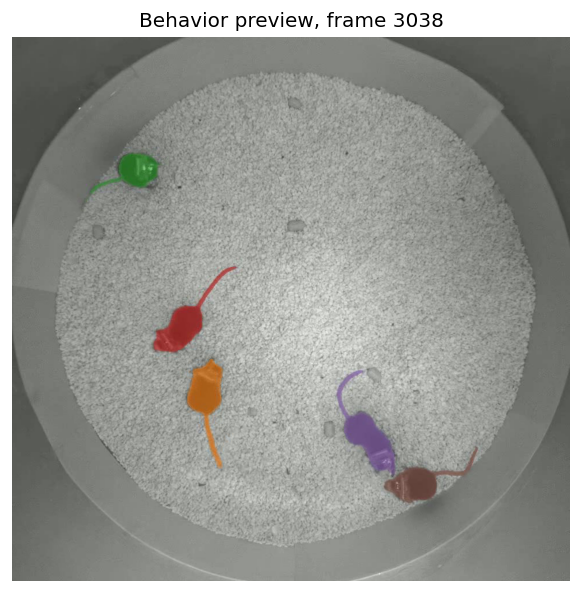

In [8]:
def read_video_frame(video_path: Path, frame_index: int) -> np.ndarray:
    if cv2 is None:
        raise ImportError("OpenCV is required for reading video frames. Install opencv-python or skip video cells.")

    capture = cv2.VideoCapture(str(video_path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame_bgr = capture.read()
    capture.release()

    if not ok:
        raise ValueError(f"Could not read frame {frame_index} from {video_path}")
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)


EXAMPLE_FRAME = START_FRAME + 120
preview_path = BEHAVIOR_WITH_MASK_PATH if BEHAVIOR_WITH_MASK_PATH.exists() else BEHAVIOR_MP4_PATH
preview_frame = read_video_frame(preview_path, EXAMPLE_FRAME)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(preview_frame)
ax.set_title(f"Behavior preview, frame {EXAMPLE_FRAME}")
ax.set_axis_off()
plt.show()


## 7. Load packed SAM2 masks

`segment_mask.pickle` stores each binary mask with `numpy.packbits`. The helper functions below unpack only the requested frame. This keeps memory use modest and makes the notebook easier to run on a laptop.


In [9]:
def load_packed_segments(mask_path: Path) -> list[Any]:
    with gzip.open(mask_path, "rb") as handle:
        segments = pickle.load(handle)
    print(f"Loaded packed masks for {len(segments)} behavior-video frames")
    return segments


def unpack_mask(packed_mask: np.ndarray | bytes, shape: tuple[int, int] = FRAME_SHAPE) -> np.ndarray:
    n_pixels = int(np.prod(shape))
    mask = np.unpackbits(np.asarray(packed_mask, dtype=np.uint8), count=n_pixels)
    return mask.reshape(shape).astype(bool)


def unpack_frame_masks(
    packed_segments: list[Any],
    frame_index: int,
    shape: tuple[int, int] = FRAME_SHAPE,
) -> dict[int, np.ndarray]:
    frame = packed_segments[frame_index]
    if frame is None:
        return {}
    return {int(obj_id): unpack_mask(packed_mask, shape) for obj_id, packed_mask in frame.items()}


packed_segments = load_packed_segments(SAM2_MASK_PATH)
example_masks = unpack_frame_masks(packed_segments, EXAMPLE_FRAME)
print(f"Frame {EXAMPLE_FRAME} contains masks for SAM2 object ids: {sorted(example_masks)}")


Loaded packed masks for 10805 behavior-video frames
Frame 3038 contains masks for SAM2 object ids: [1, 2, 3, 4, 5]


## 8. Overlay masks reconstructed from `segment_mask.pickle`

This reproduces the key visual quality-control step without depending on the pre-rendered `behavior_with_mask.avi` file.


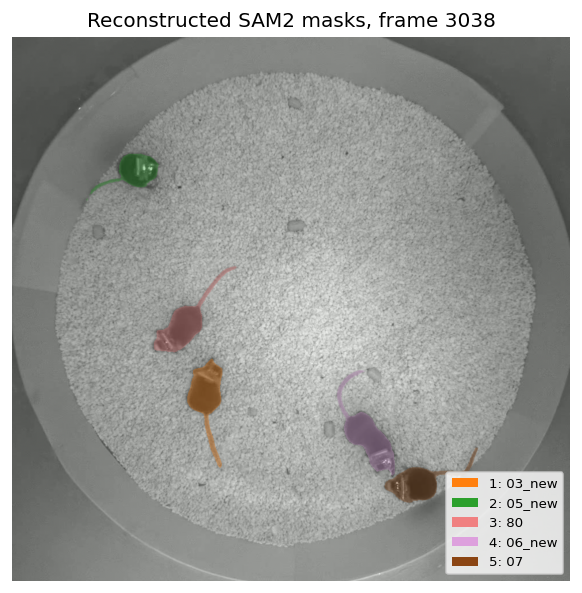

In [10]:
def overlay_masks_on_frame(
    frame_rgb: np.ndarray,
    masks: dict[int, np.ndarray],
    colors: dict[int, str],
    alpha: float = 0.35,
) -> np.ndarray:
    overlay = frame_rgb.astype(float) / 255.0
    for obj_id, mask in masks.items():
        color_rgb = np.asarray(mcolors.to_rgb(colors[obj_id]))
        overlay[mask] = (1 - alpha) * overlay[mask] + alpha * color_rgb
    return np.clip(overlay, 0, 1)


raw_frame = read_video_frame(BEHAVIOR_MP4_PATH, EXAMPLE_FRAME)
overlay_frame = overlay_masks_on_frame(raw_frame, example_masks, ANIMAL_COLORS)
legend_handles = [
    Patch(facecolor=ANIMAL_COLORS[obj_id], label=f"{obj_id}: {ANIMAL_ID_TO_NAME[obj_id]}")
    for obj_id in sorted(example_masks)
]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(overlay_frame)
ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=8)
ax.set_title(f"Reconstructed SAM2 masks, frame {EXAMPLE_FRAME}")
ax.set_axis_off()
plt.show()


## 9. Detect animal interaction events from masks

Operational definition used here: two animals are considered in contact when the minimum Euclidean distance between their foreground mask pixels is below `INTERACTION_THRESHOLD_PX`.


In [12]:
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

INTERACTION_THRESHOLD_PX = 20
INTERACTION_FRAME_START = START_FRAME
INTERACTION_FRAME_END = END_FRAME
INTERACTION_MAX_WORKERS = 32
INTERACTION_CACHE_PATH = OUTPUT_DIR / (
    f"interactions_frames_{INTERACTION_FRAME_START}_{INTERACTION_FRAME_END}_"
    f"threshold_{INTERACTION_THRESHOLD_PX}px.pkl"
)


def min_mask_distance(mask_a: np.ndarray, mask_b: np.ndarray) -> float:
    if not mask_a.any() or not mask_b.any():
        return float("inf")
    distance_to_b = distance_transform_edt(~mask_b)
    return float(distance_to_b[mask_a].min())


def connected_components_from_pairs(pairs: list[tuple[int, int, float]]) -> list[list[int]]:
    graph: dict[int, set[int]] = {}
    for obj_a, obj_b, _distance in pairs:
        graph.setdefault(obj_a, set()).add(obj_b)
        graph.setdefault(obj_b, set()).add(obj_a)

    groups = []
    visited = set()
    for node in sorted(graph):
        if node in visited:
            continue
        stack = [node]
        component = set()
        while stack:
            current = stack.pop()
            if current in component:
                continue
            component.add(current)
            stack.extend(graph.get(current, set()) - component)
        visited |= component
        groups.append(sorted(component))
    return groups


def detect_frame_interactions(
    frame_masks: dict[int, np.ndarray],
    threshold_px: float,
) -> tuple[list[tuple[int, int, float]], list[list[int]]]:
    pairs = []
    distance_maps = {
        obj_id: distance_transform_edt(~mask)
        for obj_id, mask in frame_masks.items()
        if mask.any()
    }
    for obj_a, obj_b in itertools.combinations(sorted(frame_masks), 2):
        mask_a = frame_masks[obj_a]
        if obj_b not in distance_maps or not mask_a.any():
            distance_px = float("inf")
        else:
            distance_px = float(distance_maps[obj_b][mask_a].min())
        if distance_px < threshold_px:
            pairs.append((obj_a, obj_b, distance_px))
    return pairs, connected_components_from_pairs(pairs)


def _process_single_frame(
    packed_segments: list[Any],
    frame_index: int,
    threshold_px: float,
) -> dict[str, Any]:
    frame_masks = unpack_frame_masks(packed_segments, frame_index)
    pairs, groups = detect_frame_interactions(frame_masks, threshold_px)
    return {
        "frame": frame_index,
        "aligned_index": frame_index - START_FRAME,
        "pairs": pairs,
        "groups": groups,
    }


def compute_interactions(
    packed_segments: list[Any],
    frame_start: int,
    frame_end: int,
    threshold_px: float,
    cache_path: Path | None = None,
    force: bool = False,
    max_workers: int = INTERACTION_MAX_WORKERS,
) -> list[dict[str, Any]]:
    if cache_path is not None and cache_path.exists() and not force:
        with open(cache_path, "rb") as handle:
            cached = pickle.load(handle)
        print(f"Loaded cached interactions from {cache_path}")
        return cached

    frame_indices = list(range(frame_start, frame_end + 1))
    if max_workers <= 1:
        records = [
            _process_single_frame(packed_segments, frame_index, threshold_px)
            for frame_index in tqdm(frame_indices, desc="Detecting interactions")
        ]
    else:
        records_by_frame: dict[int, dict[str, Any]] = {}
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {
                executor.submit(_process_single_frame, packed_segments, frame_index, threshold_px): frame_index
                for frame_index in frame_indices
            }
            for future in tqdm(as_completed(futures), total=len(futures), desc="Detecting interactions"):
                record = future.result()
                records_by_frame[record["frame"]] = record
        records = [records_by_frame[frame_index] for frame_index in frame_indices]

    if cache_path is not None:
        with open(cache_path, "wb") as handle:
            pickle.dump(records, handle)
        print(f"Saved interactions to {cache_path}")
    return records


interaction_records = compute_interactions(
    packed_segments,
    INTERACTION_FRAME_START,
    INTERACTION_FRAME_END,
    INTERACTION_THRESHOLD_PX,
    cache_path=INTERACTION_CACHE_PATH,
    max_workers=INTERACTION_MAX_WORKERS,
)

n_contact_frames = sum(bool(record["pairs"]) for record in interaction_records)
print(f"Analyzed {len(interaction_records)} frames")
print(f"Frames with at least one contact pair: {n_contact_frames}")
print(f"Workers used: {INTERACTION_MAX_WORKERS}")


Detecting interactions: 100%|██████████| 7601/7601 [01:17<00:00, 98.33it/s] 

Saved interactions to /data/home/angran/BBNC/code/PICO/PICO_release/Airscope_toolbox/Data_release/experiments/muiti_animal_interaction/outputs/interactions_frames_2918_10518_threshold_20px.pkl
Analyzed 7601 frames
Frames with at least one contact pair: 3604
Workers used: 32


## 10. Summarize interaction partners for one focal animal

This cell converts pairwise contacts into binary time courses. The example focal animal is SAM2 object id `5`, corresponding to animal `07`.


In [13]:
FOCAL_ID = 5


def interaction_records_to_binary(
    records: list[dict[str, Any]],
    focal_id: int,
) -> dict[int, np.ndarray]:
    partners = {obj_id: np.zeros(len(records), dtype=np.uint8) for obj_id in ANIMAL_ID_TO_NAME if obj_id != focal_id}
    for i, record in enumerate(records):
        for obj_a, obj_b, _distance in record["pairs"]:
            if obj_a == focal_id and obj_b in partners:
                partners[obj_b][i] = 1
            elif obj_b == focal_id and obj_a in partners:
                partners[obj_a][i] = 1
    return partners


focal_interactions = interaction_records_to_binary(interaction_records, FOCAL_ID)
summary_rows = []
for partner_id, binary in focal_interactions.items():
    summary_rows.append({
        "focal_id": FOCAL_ID,
        "focal_animal": ANIMAL_ID_TO_NAME[FOCAL_ID],
        "partner_id": partner_id,
        "partner_animal": ANIMAL_ID_TO_NAME[partner_id],
        "contact_frames": int(binary.sum()),
        "contact_seconds": float(binary.sum() / VIDEO_FPS),
    })

if pd is not None:
    display(pd.DataFrame(summary_rows))
else:
    for row in summary_rows:
        print(row)


,focal_id,focal_animal,partner_id,partner_animal,contact_frames,contact_seconds
0,5,07,1,03_new,322,32.2
1,5,07,2,05_new,301,30.1
2,5,07,3,80,517,51.7
3,5,07,4,06_new,237,23.7


## 11. Plot a focal-animal interaction raster

Each horizontal row is one interaction partner. Colored ticks mark frames in which the focal animal was within the mask-distance threshold of that partner.


Saved /data/home/angran/BBNC/code/PICO/PICO_release/Airscope_toolbox/Data_release/experiments/muiti_animal_interaction/outputs/interaction_raster_focal_5_07.pdf


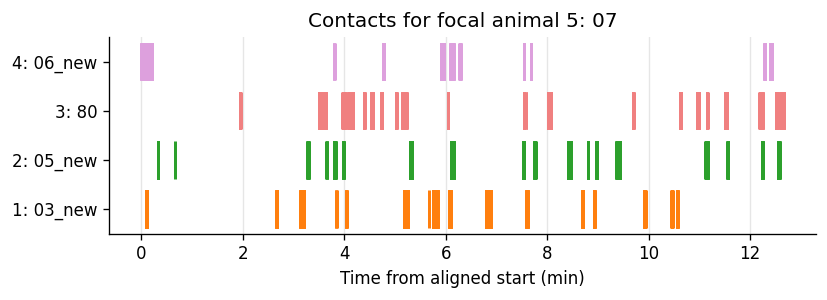

In [14]:
def plot_interaction_raster(
    interactions_by_partner: dict[int, np.ndarray],
    records: list[dict[str, Any]],
    focal_id: int,
    output_path: Path | None = None,
) -> None:
    if not records:
        raise ValueError("No interaction records to plot")

    aligned_indices = np.asarray([record["aligned_index"] for record in records])
    time_min = aligned_indices / VIDEO_FPS / 60.0

    fig, ax = plt.subplots(figsize=(7, 2.6))
    for row, (partner_id, binary) in enumerate(sorted(interactions_by_partner.items())):
        event_times = time_min[binary.astype(bool)]
        ax.vlines(
            event_times,
            row + 0.12,
            row + 0.88,
            color=ANIMAL_COLORS[partner_id],
            linewidth=1.8,
        )

    y_positions = np.arange(len(interactions_by_partner)) + 0.5
    y_labels = [f"{pid}: {ANIMAL_ID_TO_NAME[pid]}" for pid in sorted(interactions_by_partner)]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Time from aligned start (min)")
    ax.set_title(f"Contacts for focal animal {focal_id}: {ANIMAL_ID_TO_NAME[focal_id]}")
    ax.set_ylim(0, len(interactions_by_partner))
    ax.grid(axis="x", color="0.9")
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")
        print(f"Saved {output_path}")
    plt.show()


interaction_raster_path = OUTPUT_DIR / f"interaction_raster_focal_{FOCAL_ID}_{ANIMAL_ID_TO_NAME[FOCAL_ID]}.pdf"
plot_interaction_raster(focal_interactions, interaction_records, FOCAL_ID, interaction_raster_path)


## 12. Plot mouse center trajectories from `data_aligned.mat`

The aligned `.mat` file includes centroid trajectories derived from the same behavior-video coordinate system. This plot gives a quick check that the tracked animals occupy plausible regions of the arena.


Saved /data/home/angran/BBNC/code/PICO/PICO_release/Airscope_toolbox/Data_release/experiments/muiti_animal_interaction/outputs/mouse_center_trajectories_example_window.pdf


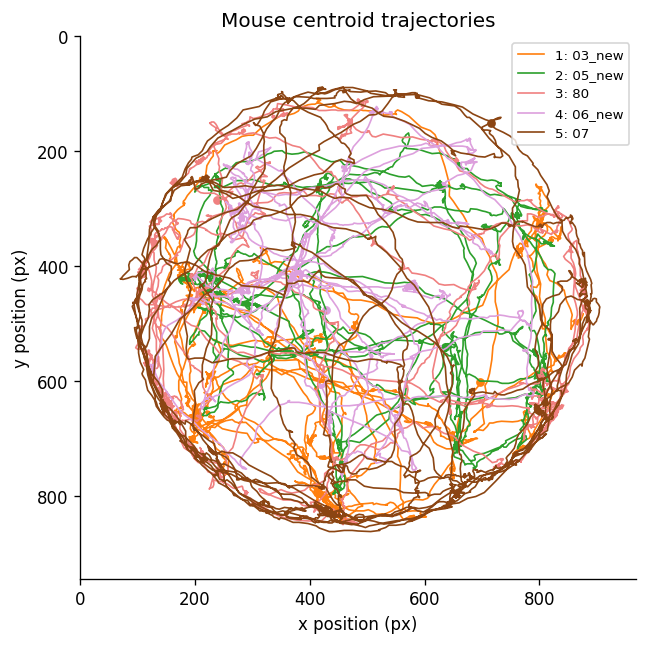

In [15]:
def plot_mouse_center_trajectories(
    aligned: dict[str, Any],
    frame_slice: slice,
    output_path: Path | None = None,
) -> None:
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    for obj_id, animal_name in ANIMAL_ID_TO_NAME.items():
        center = np.asarray(aligned[f"mouse_center_{animal_name}"])
        if center.shape[0] != 2:
            center = center.T
        x = center[0, frame_slice]
        y = center[1, frame_slice]
        ax.plot(x, y, color=ANIMAL_COLORS[obj_id], linewidth=1.0, label=f"{obj_id}: {animal_name}")
        ax.scatter(x[0], y[0], color=ANIMAL_COLORS[obj_id], s=18, marker="o")

    ax.set_xlim(0, FRAME_SHAPE[1])
    ax.set_ylim(FRAME_SHAPE[0], 0)
    ax.set_aspect("equal")
    ax.set_xlabel("x position (px)")
    ax.set_ylabel("y position (px)")
    ax.set_title("Mouse centroid trajectories")
    ax.legend(loc="upper right", fontsize=8, frameon=True)
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")
        print(f"Saved {output_path}")
    plt.show()


trajectory_path = OUTPUT_DIR / "mouse_center_trajectories_example_window.pdf"
plot_mouse_center_trajectories(aligned_data, slice(START_FRAME, END_FRAME), trajectory_path)


## 13. Overlay interactions on calcium traces

This figure links the behavior-derived contact epochs to cortical calcium activity. The left column shows z-scored activity heatmaps for selected regions. The right column zooms into the same time window used for interaction detection and overlays colored contact epochs for the focal animal.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

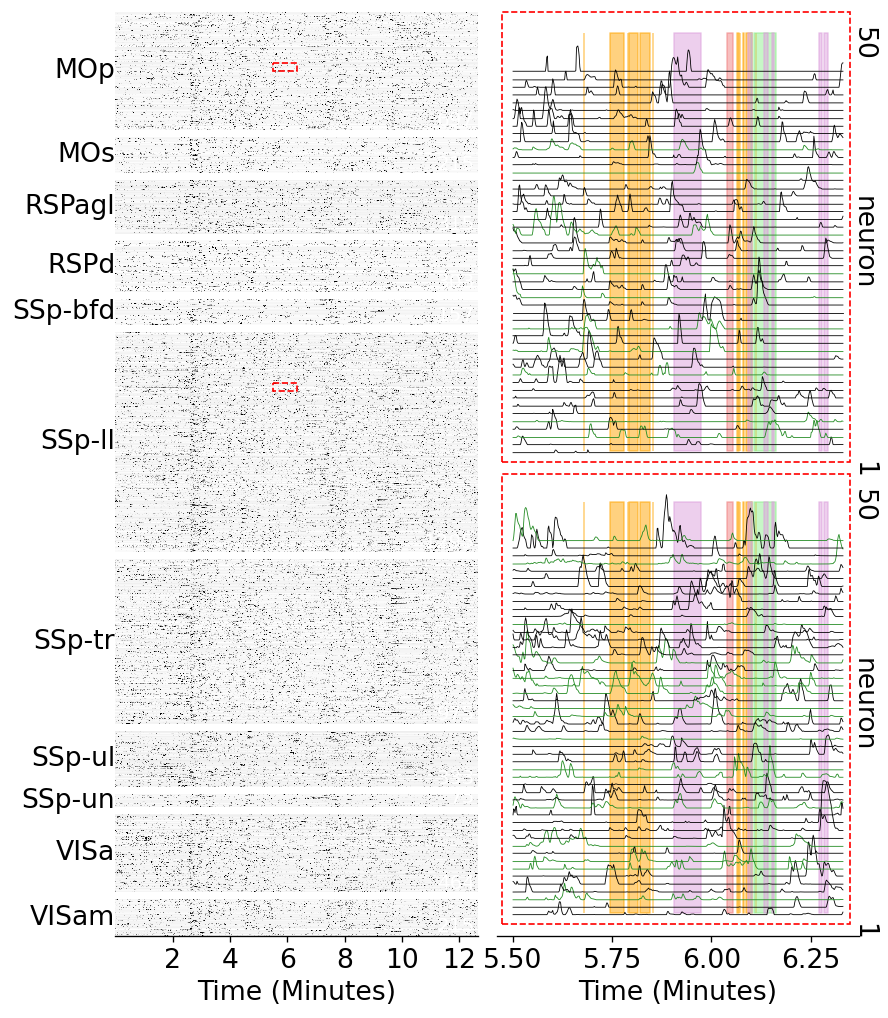

In [22]:
import pickle
from datetime import datetime
import numpy as np
import scipy
from matplotlib import pyplot as plt, gridspec, patches
from matplotlib.patches import Rectangle
from scipy.stats import zscore


def plot_neuron_activity(calcium_data, stimulus, cortical_name, interest_names, regions, neuron_start, neuron_end,
                         frame_start, frame_end,
                         save_path):
    """
    This function visualizes neuron activity for specified brain regions and time frames.

    Parameters:
    - calcium_data: 2D array with neuron activity data.
    - stimulus: 1D array with stimulus time points.
    - cortical_name: List of names for neurons corresponding to cortical regions.
    - interest_names: List of brain regions of interest to include in the plot.
    - regions: List of specific regions to highlight in the plot.
    - neuron_start, neuron_end: Range of neuron indices to display.
    - frame_start, frame_end: Frame range for the x-axis.

    Returns:
    - A matplotlib plot showing heatmaps and neuron activity for selected brain regions.
    """
    # Organize calcium data by region based on the provided cortical names
    assigned_dict = {name: [] for name in interest_names}
    for i, name in enumerate(cortical_name):
        if name in interest_names:
            tmp = zscore(calcium_data[i])
            if not np.isnan(tmp).any():  # 只有当 tmp 不包含 NaN 时才添加
                assigned_dict[name].append(tmp)

    # Remove regions with insufficient data (fewer than 10 neurons)
    keys_to_pop = [key for key, value in assigned_dict.items() if len(value) < 50]
    for key in keys_to_pop:
        assigned_dict.pop(key)

    # Plot setup: defining regions and spacing
    num_regions = len(assigned_dict)
    region_names = list(assigned_dict.keys())
    height_ratios = [len(assigned_dict[region]) for region in region_names]
    gap = 40  # Gap between rows in the heatmap
    total_rows = sum(height_ratios) + (num_regions - 1) * gap

    fig = plt.figure(figsize=(8, 10))
    gs = gridspec.GridSpec(total_rows, 2, width_ratios=[1, 1])

    # Left column: heatmaps of neuron activity per region
    ax_left = []
    start_row = 0
    for i in range(num_regions):
        row_span = height_ratios[i]
        ax = fig.add_subplot(gs[start_row:start_row + row_span, 0])
        heatmap_data = np.array(assigned_dict[region_names[i]])
        # Randomly reorder neurons within each region for display
        perm = np.random.permutation(heatmap_data.shape[0])
        heatmap_data = heatmap_data[perm]
        ax.imshow(heatmap_data, aspect='auto', cmap='gray_r', interpolation='nearest', vmin=np.percentile(heatmap_data, 0.5), vmax=np.percentile(heatmap_data, 99.5))
        if i < num_regions - 1:
            ax.axis("off")
        ax_left.append(ax)
        start_row += row_span + gap

    # Define x-axis time labels in minutes
    frame_number = calcium_data.shape[1]
    frame_interval = 0.1  # 100 ms intervals
    total_seconds = frame_number * frame_interval
    total_minutes = int(total_seconds // 60)
    minute_ticks = [int(minute * 60 / frame_interval) for minute in range(0, total_minutes + 1, 2) if minute]
    minute_labels = [minute for minute in range(0, total_minutes + 1, 2) if minute]

    ax_left[-1].spines['top'].set_visible(False)
    ax_left[-1].spines['right'].set_visible(False)
    ax_left[-1].spines['left'].set_visible(False)
    ax_left[-1].set_yticks([])
    ax_left[-1].set_xticks(minute_ticks)
    ax_left[-1].set_xticklabels(minute_labels)
    ax_left[-1].set_xlabel("Time (Minutes)", fontsize=16)
    ax_left[-1].tick_params(axis='x', labelsize=16)

    # Label each heatmap with region names and neuron count
    for i, ax in enumerate(ax_left):
        ax.text(-5, len(assigned_dict[region_names[i]]) // 2, region_names[i][:-1], va='center', ha='right', fontsize=16)
        length_value = len(assigned_dict[region_names[i]])
        ax.text(0.99, 0, str(length_value), color='white', va='bottom', ha='right', transform=ax.transAxes,
                fontsize=12)


    # Plot right column: line plots of neuron activity per region
    for idx, region in enumerate(regions):
        region_id = region_names.index(region)
        ax_r = fig.add_subplot(gs[idx * total_rows // len(regions):(idx + 1) * total_rows // len(regions), 1])

        offset = 40
        for i, neuron_idx in enumerate(np.arange(neuron_start, neuron_end)):
            data = assigned_dict[region][neuron_idx]
            color = 'black' if np.any(data > 10) else 'forestgreen'
            ax_r.plot(np.arange(frame_start, frame_end) / 10.0 / 60,
                      data[frame_start:frame_end] * 20 + i * offset,
                      linewidth=0.5, color=color, label=f"Region: {region}")

        # Set varying rectangle boundaries for annotation based on region count
        bbox = ax_r.get_position()
        if len(regions) == 2:
            x0, y0 = bbox.x0 - 0.02, bbox.y0 + 0.01
            width, height = bbox.width + 0.01, bbox.height-0.01
        # adjust by your self
        elif len(regions) == 3:
            x0, y0 = bbox.x0 - 0.01, bbox.y0 + 0.02
            width, height = bbox.width + 0.015, bbox.height - 0.01
        else:
            x0, y0 = bbox.x0 - 0.015, bbox.y0
            width, height = bbox.width + 0.02, bbox.height

        # Add dashed red rectangle for emphasis
        rect = patches.Rectangle((x0, y0), width, height, linewidth=1, edgecolor='red',
                                 linestyle='--', transform=ax_r.figure.transFigure, facecolor="none")
        ax_r.figure.add_artist(rect)

        ax_r.text(1.01, 0.5, "neuron", color='black', va='center', ha='center', transform=ax_r.transAxes,
                  fontsize=16, rotation=-90)
        ax_r.text(1.01, 0.01, "1", color='black', va='center', ha='center', transform=ax_r.transAxes,
                  fontsize=16, rotation=-90)
        ax_r.text(1.01, 0.93, str(neuron_end - neuron_start), color='black', va='center', ha='center',
                  transform=ax_r.transAxes, fontsize=16, rotation=-90)

        # Highlight selected neuron range in the heatmap
        rect = Rectangle((frame_start, neuron_start), frame_end - frame_start,
                         neuron_end - neuron_start, linewidth=1, edgecolor='red', facecolor='none', linestyle='--')
        ax_left[region_id].add_patch(rect)

        color_dict = {1: "orange", 2: "lightgreen", 3: "lightcoral", 4: "plum", 5: "saddlebrown"}
        # color_dict = {1: "goldenrod", 2: "limegreen", 3: "lightcoral", 4: "orchid", 5: "saddlebrown"}


        #################### plot stimulus
        behavior_time = (np.arange(frame_number) / 10.0 / 60)[frame_start:frame_end]
        for key, value in stimulus.items():
            behavior_list = (value[frame_start:frame_end] == 1).astype(np.int16)

            start_time = behavior_time[0]
            current_behavior = behavior_list[0]

            for j in range(1, len(behavior_list)):
                if behavior_list[j] != current_behavior:  # Behavior change
                    # Color the segment for the previous behavior
                    if current_behavior == 1:
                        ax_r.fill_between([start_time, behavior_time[j - 1]], y1=0.03, y2=2157,
                                          color=color_dict[key], alpha=0.5,
                                          )

                    # Update start time and current behavior
                    start_time = behavior_time[j]
                    current_behavior = behavior_list[j]

                # Finally, fill the last segment
            if current_behavior == 1:
                ax_r.fill_between([start_time, behavior_time[-1]], y1=0.03, y2=2157,
                                  color=color_dict[key], alpha=0.5,
                                  )


        if idx == len(regions) - 1:

            ax_r.spines['top'].set_visible(False)
            ax_r.spines['right'].set_visible(False)
            ax_r.spines['left'].set_visible(False)
            ax_r.set_yticks([])
            ax_r.set_xlabel("Time (Minutes)", fontsize=16)
            ax_r.tick_params(axis='x', labelsize=16)
        else:
            ax_r.axis("off")

    plt.subplots_adjust(hspace=0, wspace=0.05)
    plt.savefig(save_path)

    plt.show()


REGIONS_TO_PLOT = ["MOp1", "SSp-ll1"]
TRACE_START = 300
N_TRACES_PER_REGION = 50
CALCIUM_FRAME_START = 3300
CALCIUM_FRAME_END = 3800

animal_name = ANIMAL_ID_TO_NAME[FOCAL_ID]
calcium_data = np.asarray(aligned_data[f"calcium_{animal_name}"], dtype=float)
cortical_name = [name.strip() for name in clean_matlab_strings(aligned_data[f"neuron_name_{animal_name}"])]
interest_names = sorted(set(cortical_name))

calcium_output_path = OUTPUT_DIR / f"calcium_interaction_overlay_{animal_name}.pdf"

plot_neuron_activity(
    calcium_data,
    focal_interactions,
    cortical_name,
    interest_names,
    REGIONS_TO_PLOT,
    TRACE_START,
    TRACE_START + N_TRACES_PER_REGION,
    CALCIUM_FRAME_START,
    CALCIUM_FRAME_END,
    save_path=str(calcium_output_path),
)


## 14. Neuron spatial distribution by brain region (all 5 animals)

Each subplot shows the FOV footprint of one animal. Dots are individual neurons coloured by cortical region assignment.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Saved /data/home/angran/BBNC/code/PICO/PICO_release/Airscope_toolbox/Data_release/experiments/muiti_animal_interaction/outputs/neuron_region_scatter_all_animals.pdf


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

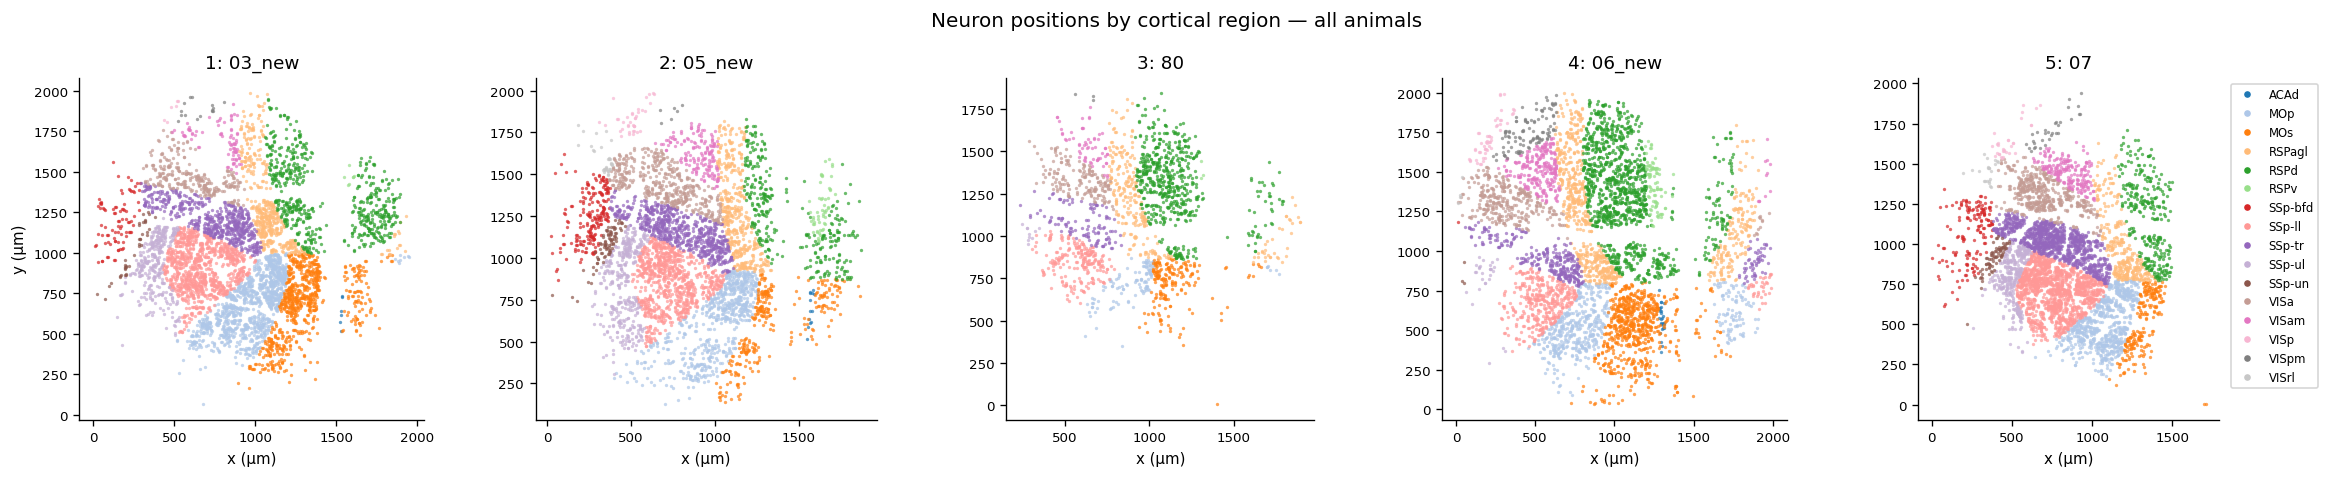

In [23]:
import matplotlib.cm as cm

def plot_neuron_region_scatter(
    aligned: dict,
    output_path: Path | None = None,
) -> None:
    n_animals = len(ANIMAL_ID_TO_NAME)
    fig, axes = plt.subplots(1, n_animals, figsize=(4 * n_animals, 4), squeeze=False)

    # Collect all region names across all animals for a consistent colour map
    all_regions: set[str] = set()
    for animal_name in ANIMAL_ID_TO_NAME.values():
        labels = clean_matlab_strings(aligned[f"neuron_name_{animal_name}"])
        all_regions.update(labels.tolist())
    sorted_regions = sorted(all_regions)
    region_colors = {
        region: cm.tab20(i % 20) for i, region in enumerate(sorted_regions)
    }

    for col, (obj_id, animal_name) in enumerate(ANIMAL_ID_TO_NAME.items()):
        ax = axes[0, col]
        labels = clean_matlab_strings(aligned[f"neuron_name_{animal_name}"])
        centers = np.asarray(aligned[f"neuron_center_{animal_name}"], dtype=float)
        # shape should be (2, N) or (N, 2); normalise to (2, N)
        if centers.ndim == 2 and centers.shape[0] != 2:
            centers = centers.T

        plotted_regions: dict[str, bool] = {}
        for region in sorted_regions:
            mask = labels == region
            if not mask.any():
                continue
            ax.scatter(
                centers[0, mask],
                centers[1, mask],
                s=4,
                color=region_colors[region],
                alpha=0.7,
                linewidths=0,
                label=region if region not in plotted_regions else "_nolegend_",
            )
            plotted_regions[region] = True

        ax.set_title(f"{obj_id}: {animal_name}", fontsize=11)
        ax.set_aspect("equal")
        ax.set_xlabel("x (µm)", fontsize=9)
        if col == 0:
            ax.set_ylabel("y (µm)", fontsize=9)
        ax.tick_params(labelsize=8)

    # Single shared legend on the last axis
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=region_colors[r],
                   markersize=5, label=r[:-1] if r.endswith(("1","2","3","4","5","6")) else r)
        for r in sorted_regions
    ]
    axes[0, -1].legend(
        handles=handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=7,
        frameon=True,
        ncol=1,
    )

    fig.suptitle("Neuron positions by cortical region — all animals", fontsize=12)
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")
        print(f"Saved {output_path}")
    plt.show()


region_scatter_path = OUTPUT_DIR / "neuron_region_scatter_all_animals.pdf"
plot_neuron_region_scatter(aligned_data, output_path=region_scatter_path)
